# **Análisis Predictivo de Precios para Alojamientos de Airbnb en Nueva York**

### *Abstract*

Este proyecto se sumerge en el mercado de alquileres temporales de **Airbnb** en #**Nueva York**, utilizando el *dataset* público *"Airbnb_Open_Dataset Oficial.csv"* en el ***GitHub*** publico. El objetivo principal es desarrollar y evaluar un modelo de **Machine Learning** capaz de predecir el precio por noche de un alojamiento, identificando los factores más influyentes para sus tarifas. Tras un riguroso **pipeline** de limpieza de datos, análisis exploratorio *(EDA)* e ingeniería de características *(donde se crearon **7** nuevas variables, incluyendo la antigüedad de la propiedad y la presencia de servicios clave)*, se entrenaron dos modelos de regresión. El modelo final, un **RandomForestRegressor**, logró un coeficiente de determinación ***(R²)* de 0.325**, superando drásticamente a un modelo lineal de base. El análisis de importancia de características reveló que la **ubicación geográfica *(`lat`, `long`)** y la **disponibilidad anual** son los predictores más potentes. El proyecto concluye que, si bien el modelo actual proporciona una herramienta valiosa para la estimación de precios, la precisión podría mejorarse significativamente enriqueciendo el **dataset** con datos sobre la **calidad y los servicios específicos de cada propiedad**.

### *Objetivo del Proyecto*

En el competitivo mercado de **Airbnb** pricipalmente el **Airbnb** de ***Nueva York***. Fijar un precio óptimo es un desafío crucial tanto para anfitriones, que buscan maximizar su rentabilidad, como para huéspedes, que desean evaluar si una tarifa es justa. El problema central es la falta de una referencia de precios objetiva.

Por lo tanto, el objetivo de este proyecto es **construir un modelo de regresión que prediga el precio de un alojamiento en Nueva York**, sirviendo como base para:
-   **Ayudar a los anfitriones a posicionar sus propiedades con un precio competitivo.**
-   **Permitir a los huéspedes evaluar si el precio de un listado es adecuado.**
-   **Identificar y cuantificar los atributos de una propiedad que tienen el mayor impacto en su valor.**

### *Hipótesis*

Se aborda este problema mediante un enfoque de **aprendizaje supervisado**, específicamente una tarea de **regresión**, utilizando el `price` como variable objetivo. El análisis se guió por las siguientes hipótesis, las cuales fueron evaluadas tanto en el EDA como con los resultados del modelo final:

1.  **Hipótesis de Ubicación:** El distrito (`distritos`) y la ubicación exacta (`lat`, `long`) son los factores más determinantes en la variación de los precios.
    *   **Resultado: Confirmada.** El análisis de importancia de características del modelo **Random Forest** posicionó a `lat` y `long` como las dos variables **más influyentes**.

2.  **Hipótesis de Tipo de Propiedad:** El tipo de habitación (`room_type`) tiene un impacto significativo y directo sobre el precio.
    *   **Resultado: Confirmada.** Ser una **"habitación privada"** (`room_type_Private room`) se encuentra entre las **10 características más importantes para el modelo**.

3.  **Hipótesis de Valor Añadido:** La creación de nuevas características que mejorarán la precisión predictiva.
    *   **Resultado: Confirmada.** La característica `antiguedad_propiedad`, creada por nosotros, se posicionó como la quinta variable más importante, demostrando el valor de enriquecer los datos. La presencia de `tiene_cocina` también fue relevante, aunque en menor medida.


# *1. Librerías*

In [1]:
# 1. Configuración de las Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# 1.1. Librerías de Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

# 1.2. Configuración de visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("1. Librerías cargadas exitosamente")

1. Librerías cargadas exitosamente


# **Justificación de la Configuración del Entorno**

Para llevar a cabo este análisis, se ha configurado un entorno de trabajo con un conjunto de librerías de Python especializadas, cada una cumpliendo un rol fundamental en el ciclo de vida de un proyecto de ciencia de datos para asegurar un flujo de trabajo robusto, reproducible y eficiente.

# **Librerías Fundamentales para el Manejo de Datos:**

**Pandas:** Es la herramienta principal para la manipulación y análisis de datos. Se utiliza para cargar el dataset, realizar la limpieza exhaustiva (manejo de nulos, corrección de tipos), y estructurar la información en DataFrames, que son la base de todo el proyecto.

**NumPy:** Proporciona soporte para operaciones numéricas eficientes y de alto rendimiento. Es esencial para cálculos matemáticos y el manejo de arrays numéricos que Scikit-Learn utiliza internamente.

# **Librerías de Visualización:**

**Matplotlib y Seaborn:** Son las librerías estándar para la visualización de datos en Python. Se utilizan de forma intensiva en la fase de Análisis Exploratorio de Datos (EDA) para generar los gráficos (histogramas, boxplots, mapas de calor) que nos permiten entender la distribución de los datos, identificar patrones y validar nuestras hipótesis de forma visual. Se ha configurado un tema (whitegrid) y un tamaño de figura por defecto para mantener la consistencia estética en todo el informe.

# **Librerías de Machine Learning (Scikit-Learn):**

Para garantizar las mejores prácticas de la industria, se ha adoptado un enfoque basado en Pipelines para encapsular el preprocesamiento y el modelado.
Preprocesamiento de Datos:

**ColumnTransformer:** Permite aplicar diferentes transformaciones a distintas columnas del dataset. Es clave para manejar datos heterogéneos, aplicando escalado a las variables numéricas y codificación a las categóricas de forma organizada.

**StandardScaler:** Normaliza las características numéricas, asegurando que todas tengan una media de 0 y una desviación estándar de 1. Esto es crucial para que los algoritmos de regresión no se vean sesgados por variables con escalas diferentes.

**OneHotEncoder:** Convierte las variables categóricas en un formato numérico que los modelos puedan procesar, evitando la introducción de un orden artificial entre categorías.

**Pipeline:** Encapsula secuencialmente los pasos de preprocesamiento y el modelo. Esto simplifica el flujo de trabajo, previene la fuga de datos (data leakage) y facilita la implementación del modelo en producción.

# **Modelado y Validación:**

**sklearn.model_selection:** Contiene train_test_split para dividir los datos de forma segura en conjuntos de entrenamiento y prueba, un paso fundamental para evaluar la capacidad de generalización del modelo.

**LinearRegression:** Se utilizará para construir nuestro modelo baseline. Este modelo simple nos proporciona una referencia de rendimiento inicial contra la cual comparar modelos más complejos.

**RandomForestRegressor:** Es la implementación de nuestro modelo principal. Se elige el Random Forest por su alta precisión, su capacidad para capturar interacciones no lineales y su robustez frente al sobreajuste.

**sklearn.metrics:** Proporciona las funciones para una evaluación cuantitativa del rendimiento, como r2_score (R²), mean_absolute_error (MAE) y mean_squared_error (para calcular el RMSE).

# **Librerías de Interpretabilidad de Modelos (XAI):**

**SHAP (SHapley Additive exPlanations):** Se importa esta librería avanzada para la fase final de interpretación del modelo. Su inclusión demuestra el compromiso de ir más allá de la simple predicción para entender por qué el modelo toma sus decisiones, añadiendo una capa crucial de explicabilidad y confianza en los resultados del proyecto.

Esta configuración integral nos proporciona todas las herramientas necesarias para abordar el proyecto de manera sistemática, desde la carga y limpieza de datos hasta el entrenamiento, evaluación e interpretación de un modelo predictivo que no solo es preciso, sino también robusto e interpretable.

# 2. Carga y Exploración Inicial de Datos

In [2]:
# 2. Carga y Exploración Inicial de Datos

# 2.1 URL del dataset en GitHub
url = 'https://raw.githubusercontent.com/IturryCamila/Data-Science-Camila-Iturry/refs/heads/main/Airbnb_Open_Data.csv'

# DATAFRAME
try:
    df = pd.read_csv(url, low_memory=False, sep=',') # Changed sep=';' to sep=','
    print("\n✓ DataFrame creado exitosamente desde GitHub")
except Exception as e:
    print(f"\nX Error al crear el DataFrame desde GitHub: {e}")
    raise

# INFORMACION GENERAL DEL DATASET
print("\n INFORMACIÓN GENERAL")
print(f"Registros: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

print("\n ESTRUCTURA DEL DATASET")
df.info()

# PRIMEROS DATOS
print("\n PRIMERAS 5 FILAS")
display(df.head())


✓ DataFrame creado exitosamente desde GitHub

 INFORMACIÓN GENERAL
Registros: 102,599
Columnas: 26

 ESTRUCTURA DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code   

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


# **Carga de Datos:**

# ***Airbnb_Open_Dataset Oficial.csv*. Descripción de las Columnas Originales del *dataset*:**

•	***id / host_id:*** Identificadores numéricos únicos para el listado y el anfitrión, respectivamente. Se utilizaron para la identificación, pero se eliminaron antes del modelado.

•	***publicity / house_rules:*** Columnas de texto libre que contienen el título del anuncio y las reglas de la casa. Se utilizaron como fuente para la extracción de amenities.

•	***host_identity_verified:*** Variable categórica que indica si la identidad del anfitrión ha sido verificada por la plataforma.

•	***neighborhood_group / neighbourhood:*** Columnas geográficas originales que contenían información sobre los distritos y barrios, respectivamente.

# **Presentaban inconsistencias y fueron utilizadas para crear la variable limpia distritos.**

•	***lat / long:*** Coordenadas geográficas *(latitud y longitud)* del alojamiento. Es una de las características más importantes para el modelo.

•	***construction_year:*** Año de construcción de la propiedad. Se utilizó para crear la característica **antiguedad_propiedad**.

•	***room_type:*** Variable categórica que describe el tipo de alquiler *(ej. "Entire home/apt", "Private room")*.

•	***price / service_fee:*** El precio por noche y la tarifa de servicio. price es nuestra variable objetivo, y ***service_fee*** fue eliminada por problemas de fuga de datos.

•	***minimum_nights:*** Número mínimo de noches requeridas para una reserva.

•	***number_of_reviews / reviews_per_month:*** Métricas de popularidad que indican el total de reseñas y la frecuencia mensual. ***reviews_per_month*** fue eliminada por multicolinealidad.

•	***review_rate_number:*** La calificación promedio del alojamiento *(escala de **1** a **5**)*.

•	***calculated_host_listings_count:*** El número total de propiedades que gestiona un mismo anfitrión.

•	***availability_365:*** Número de días al año que la propiedad está disponible para ser reservada.

•	***instant_bookable:*** Variable categórica que indica si la propiedad se puede reservar de forma instantánea.

•	***cancellation_policy:*** Variable categórica que describe la política de cancelación ***(ej. "flexible", "moderate", "strict")***1.


### **Interpretación de la Carga de Datos y Vistazo Inicial**

El primer paso técnico del proyecto es la adquisición de los datos. Para ello, se ha implementado un script de carga robusto y reproducible.

#### **Justificación del Método de Carga:**

El código no se limita a una simple carga desde una URL. Utiliza un bloque `try-except` por las siguientes razones:

1.  **Eficiencia:** Intenta primero cargar el archivo desde el entorno local (`Airbnb_Open_Dataset Oficial.csv`). Si el archivo ya ha sido descargado, esta es la forma más rápida y no depende de una conexión a internet.
2.  **Reproducibilidad:** Si el archivo local no se encuentra (como ocurrió en la ejecución), el script automáticamente intenta descargarlo desde la URL de GitHub. Esto garantiza que cualquier persona, en cualquier máquina, pueda ejecutar este notebook y obtener los datos sin necesidad de descargarlos manualmente.
3.  **Manejo de Errores:** El script captura posibles errores tanto en la carga local como en la de la URL, proveyendo mensajes claros si algo falla.
4.  **Parámetros de Lectura:** Se ha especificado `sep=';'` porque se ha identificado que el delimitador del archivo es un punto y coma, no una coma. `low_memory=False` se utiliza para prevenir que Pandas infiera tipos de datos de forma incorrecta en columnas con valores mixtos, evitando así posibles errores de carga.

#### **Análisis del Vistazo Inicial (`.info()` y `.head()`):**

La exploración inicial nos proporciona un diagnóstico fundamental del estado de los datos crudos:

*   **Dimensiones:** El dataset consta de **103,003 filas (alojamientos) y 24 columnas (características)**. Es un conjunto de datos lo suficientemente grande para entrenar un modelo robusto.
*   **Tipos de Datos Incorrectos:** El `.info()` revela problemas críticos. Columnas que deberían ser numéricas como `price` o `lat` están cargadas como `int64`, lo que indica una posible pérdida del punto decimal. Otras como `availability_365` o `minimum_nights` están como `object` (texto), lo que significa que contienen valores no numéricos que deben ser limpiados.
*   **Valores Nulos y Datos "Sucios":** La vista previa (`.head()`) y el conteo de no nulos en `.info()` muestran la presencia de valores `NaN` (en `host name`) y de texto como `"unconfirmed"` en columnas geográficas. Esto confirma la necesidad de un proceso de limpieza profundo, que será el siguiente paso del proyecto.

# **3. Limpieza y Preprocesamiento de Datos.**

In [3]:
#INSPECCIÓN Y LIMPIEZA INICIAL

print("="*70)
print("INSPECCIÓN Y LIMPIEZA INICIAL".center(70,"="))
print("="*70)

# NULOS

nulos_totales = df.isna().sum().sum()
print(f"Total de nulos: {nulos_totales:,}")
print(f"Porcentaje de nulos: {nulos_totales/df.size*100:.2f}%")

#COLUMNAS

print("\n NULOS POR COLUMNA")
nulos_por_columna = pd.DataFrame({
    'Nulos': df.isna().sum(),
    'Porcentaje': (df.isna().sum()/df.shape[0]*100).round(2)
})
display(nulos_por_columna)

# COLUMNAS CRITICAS

columnas_criticas = nulos_por_columna[nulos_por_columna['Porcentaje'] > 40].index
if len(columnas_criticas) > 0:
  print(f"\n COLUMNAS CRITICAS (>40% nulos): {list(columnas_criticas)}")
  print("Considerar eliminar ")

# LIMPIZA DE COLUMNAS INNECESARIAS

print("\nEliminación de columnas innecesarias")

#COLUMNAS CON MAS DEL 95% DE LOS NULOS

umbral_eliminacion = 95
columnas_a_eliminar = nulos_por_columna[nulos_por_columna['Porcentaje'] > umbral_eliminacion].index.tolist()

if len(columnas_a_eliminar) > 0:
  print(f"\nColumnas con mas del {umbral_eliminacion}% de nulos: {columnas_a_eliminar}")

  df.drop(columns=columnas_a_eliminar, inplace=True)

  print(f"\nColumnas eliminadas: {columnas_a_eliminar}")

else:
  print(f"\nNo se encontraron columnas con mas del {umbral_eliminacion}% de nulos.")


# DIMENSIONES FINALES DEL DATASET:

print(f"\nDimensiones finales del dataset: {df.shape[0]:,} registros x {df.shape[1]:,} columnas")
print("\nColumnas restantes:")
print(df.columns.tolist())

# DUPLICADOS

print("="*70)
print("ANÁLISIS DE DUPLICADOS".center(70,"="))
print("="*70)
num_duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {num_duplicados} ({100*num_duplicados/len(df):.2f}%)")

# MOSTRAR DUPLICADOS

print("\nMostrar las prmuras 5 filas duplicadas")
display(df[df.duplicated()].head())

print("\n[INFO] Analizando registros duplicados...")
num_duplicados = df.duplicated().sum()
print(f"  → Se encontraron {num_duplicados} filas duplicadas. No se eliminan por ser consideradas variantes legítimas.")


====================INSPECCIÓN Y LIMPIEZA INICIAL=====================
Total de nulos: 190,769
Porcentaje de nulos: 7.15%

 NULOS POR COLUMNA


,Nulos,Porcentaje
id,0,0.00
NAME,250,0.24
host id,0,0.00
host_identity_verified,289,0.28
host name,406,0.40
neighbourhood group,29,0.03
neighbourhood,16,0.02
lat,8,0.01
long,8,0.01
country,532,0.52



 COLUMNAS CRITICAS (>40% nulos): ['house_rules', 'license']
Considerar eliminar 

Eliminación de columnas innecesarias

Columnas con mas del 95% de nulos: ['license']

Columnas eliminadas: ['license']

Dimensiones finales del dataset: 102,599 registros x 25 columnas

Columnas restantes:
['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules']
========================ANÁLISIS DE DUPLICADOS========================
Filas duplicadas encontradas: 541 (0.53%)

Mostrar las prmuras 5 filas duplicadas


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules
102058,35506831,Master Bedroom with private Bathroom & Balcony,55110690425,unconfirmed,UZeyir,Queens,Maspeth,40.74056,-73.90635,United States,...,$706,$141,1.0,1.0,11/14/2021,0.27,3.0,1.0,339.0,NaN
102059,35507383,Cozy 2 br in sunny Fort Greene apt,80193772189,verified,Sally,Brooklyn,Fort Greene,40.68701,-73.97555,United States,...,$651,$130,3.0,38.0,11/13/2021,0.27,3.0,1.0,0.0,NaN
102060,35507935,Duplex w/ Terrace @ Box House Hotel,72991962259,verified,The Box House Hotel,Brooklyn,Greenpoint,40.73756,-73.95350,United States,...,$907,$181,3.0,10.0,11/13/2021,0.08,3.0,30.0,32.0,NaN
102061,35508488,"Cozy, clean Greenpoint room with yard access",74975156081,verified,Dawn,Brooklyn,Greenpoint,40.72516,-73.95004,United States,...,$589,$118,30.0,38.0,11/13/2021,0.34,5.0,2.0,324.0,NaN
102062,35509040,2BR XL Loft: Cleaning CDC guidelines implemented,85844415221,unconfirmed,Vida,Brooklyn,Greenpoint,40.72732,-73.94185,United States,...,$356,$71,30.0,13.0,11/13/2021,0.14,4.0,28.0,336.0,NaN



[INFO] Analizando registros duplicados...
  → Se encontraron 541 filas duplicadas. No se eliminan por ser consideradas variantes legítimas.


In [4]:
# IMPUTACIONES Y CORRECCIONES (VERSIÓN CORREGIDA Y OPTIMIZADA)

print("="*70)
print("IMPUTACIÓN DE VALORES FALTANTES".center(70,"="))
print("="*70)

# CREACIÓN DE UNA COLUMNA GEOGRÁFICA LIMPIA ('distritos')
print("\nCreando columna 'distritos'")

correcciones = {'Brookln': 'Brooklyn', 'Manhatan': 'Manhattan'}
df['neighbourhood group'] = df['neighbourhood group'].replace(correcciones)
print("Errores tipográficos en 'neighbourhood group' corregidos.")

df = df[df['neighbourhood group'] != 'Unspecified'].copy()
print("Filas con 'Unspecified' eliminadas.")

# MAPA
distritos_validos = ['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
df_confiable = df[df['neighbourhood group'].isin(distritos_validos)]
mapa_barrio_a_distrito = df_confiable.drop_duplicates(subset='neighbourhood').set_index('neighbourhood')['neighbourhood group'].to_dict() # Corrected column name here
print("Mapa de referencia Barrio -> Distrito creado.")

# DEFINIR CORRECCIÓN
def corregir_distrito(row):
  distrito_actual = row['neighbourhood group']
  barrio_actual = row['neighbourhood']

  # Regla 1: Si el distrito ya es válido, es la mejor fuente.
  if distrito_actual in distritos_validos:
    return distrito_actual
  # Regla 2: Si no, intenta usar el mapa de barrios para encontrar el distrito.
  if barrio_actual in mapa_barrio_a_distrito:
    return mapa_barrio_a_distrito[barrio_actual]
  # Regla 3: Si nada funciona, es 'Desconocido'.
  return 'Desconocido'

# COLUMNA FINAL DISTRITOS
df['distritos'] = df.apply(corregir_distrito, axis=1)
print("Columna 'distritos' creada y verificada.")
print(df['distritos'].value_counts())

# CONVERSIÓN DE TIPOS DE DATOS Y LIMPIEZA DE FORMATO
print("\nConvirtiendo columnas a tipo numérico")

# Limpieza de columnas monetarias
for col in ['price', 'service fee']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(r'[$,]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')
print("'price' y 'service fee' limpiadas y convertidas a numérico.")

# Conversión de otras columnas numéricas
for col in ['Construction year', 'minimum nights', 'availability 365']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
print("Otras columnas numéricas convertidas con 'coerce'.")

# IMPUTACIÓN DE VALORES NULOS
print("\nImputando valores nulos")

# Imputación basada en lógica de negocio
df['reviews per month'] = df['reviews per month'].fillna(0)
df['number of reviews'] = df['number of reviews'].fillna(0)
df['review rate number'] = df['review rate number'].fillna(0)
df['calculated host listings count'] = df['calculated host listings count'].fillna(0)
df['minimum nights'] = df['minimum nights'].fillna(1)
df['availability 365'] = df['availability 365'].fillna(0)
print("Imputación con lógica de negocio completada.")

# Imputación con medidas estadísticas
df['Construction year'] = df['Construction year'].fillna(df['Construction year'].mode()[0])
print("'Construction year' imputado con la moda.")

# Imputación contextual
for col in ['lat', 'long', 'price', 'service fee']:
    if col in df.columns:
        df[col] = df.groupby('distritos')[col].transform(lambda x: x.fillna(x.median()))
        df[col] = df[col].fillna(df[col].median())
print("Imputación para coordenadas y precios completada.")
columnas_categoricas_restantes = df.select_dtypes(include=['object']).columns

for col in columnas_categoricas_restantes:
    if df[col].isna().sum() > 0:
        if 'review' in col:
             df[col] = df[col].fillna('No Review')
        elif 'name' in col:
             df[col] = df[col].fillna('Unnamed')
        elif 'verified' in col:
             df[col] = df[col].fillna('unconfirmed')
        else:
             df[col] = df[col].fillna('Unspecified')

print("Imputación de categóricas completada.")

print("\nProceso de Imputación y Correcciones finalizado.")

# Imputación específica para 'house_rules'
if 'house_rules' in df.columns:
    df['house_rules'] = df['house_rules'].fillna('')
    print("'house_rules' imputado con texto vacío para los nulos.")

# VERIFICACIÓN FINAL
print("\nVerificación Final Post-Imputación")
nulos_restantes = df.isna().sum().sum()
print(f"Datos nulos restantes: {nulos_restantes}")

if nulos_restantes > 0:
    print("\nColumnas con nulos restantes:")
    print(df.isna().sum()[df.isna().sum() > 0])
else:
    print("\nNo quedan valores nulos en el dataset.")

===================IMPUTACIÓN DE VALORES FALTANTES====================

Creando columna 'distritos'
Errores tipográficos en 'neighbourhood group' corregidos.
Filas con 'Unspecified' eliminadas.
Mapa de referencia Barrio -> Distrito creado.
Columna 'distritos' creada y verificada.
distritos
Manhattan        43806
Brooklyn         41856
Queens           13269
Bronx             2713
Staten Island      955
Name: count, dtype: int64

Convirtiendo columnas a tipo numérico
'price' y 'service fee' limpiadas y convertidas a numérico.
Otras columnas numéricas convertidas con 'coerce'.

Imputando valores nulos
Imputación con lógica de negocio completada.
'Construction year' imputado con la moda.
Imputación para coordenadas y precios completada.
Imputación de categóricas completada.

Proceso de Imputación y Correcciones finalizado.
'house_rules' imputado con texto vacío para los nulos.

Verificación Final Post-Imputación
Datos nulos restantes: 0

No quedan valores nulos en el dataset.


In [5]:
# LIMPIEZA Y ANÁLISIS TEMPORAL

print("="*70)
print("LIMPIEZA Y ANÁLISIS TEMPORAL".center(70,"="))
print("="*70)

print("\nPROCESAMIENTO DE FECHAS")

# CONVERTIR 'last review' A datetime
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

# VARIABLES TEMPORALES
df['year'] = df['last review'].dt.year
df['month'] = df['last review'].dt.month

# FILTRADO

print(f"\n--- Filtrando fechas anómalas ---")
registros_antes = len(df)
print(f"Registros antes del filtro: {registros_antes:,}")

año_limite = 2025

df = df[(df['year'] <= año_limite) | (df['year'].isna())].copy()

df.reset_index(drop=True, inplace=True)

print(f"Registros eliminados con fechas futuras: {registros_antes - len(df)}")
print(f"Registros después del filtro: {len(df):,}")
print("--- Filtro completado ---\n")

# DISTRIBUCIÓN DE AÑOS
print("\nDistribución de registros por años:")
distribucion_anual = df['year'].value_counts().sort_index()
print(distribucion_anual)

print("\nPorcentaje por año:")
año_pct = (distribucion_anual / len(df) * 100).round(2)
for year, pct in año_pct.items():
    print(f"{year}: {pct:.2f}%")
# JUSTIFICACIÓN Y FILTRADO TEMPORAL
registros_antiguos = (df['year'] < 2016).sum()
print(f"\nRegistros con < 2016: {registros_antiguos}")
registros_actuales = (df['year'] > 2025).sum()
print(f"\nRegistros con > 2025: {registros_actuales}")
registros_sin_fecha = df['year'].isna().sum()
print(f"\nRegistros sin fecha de reseña: {registros_sin_fecha}")

# CALCULO DE DIAS PARA LOS QUE NO TIENEN FECHA
df['tiene_review'] = (df['number of reviews'] > 0). astype (int)

last_review_dias = df['last review'].max()
df['dias_desde_last_review'] = (last_review_dias - df['last review']).dt.days
dias_max = df['dias_desde_last_review'].max()
impute_value = dias_max + 365
df['dias_desde_last_review'] = df['dias_desde_last_review'].fillna(impute_value)

print("Vista previa de las nuevas características")
print((df[['tiene_review', 'dias_desde_last_review']]))

# REGISTROS CON RESEÑAS POR AÑO-MES
df_reviews = df[df['year'].notna()].copy()
cobertura_mensual = df_reviews.groupby(['year','month']).size()
meses_por_año = df_reviews.groupby('year')['month'].nunique()
print(f"\nTotal de registros con reseñas: {len(df_reviews):,}")
print(f"\nRegistros sin reseñas: {len(df) - len(df_reviews):,}")


=====================LIMPIEZA Y ANÁLISIS TEMPORAL=====================

PROCESAMIENTO DE FECHAS

--- Filtrando fechas anómalas ---
Registros antes del filtro: 102,599
Registros eliminados con fechas futuras: 3
Registros después del filtro: 102,596
--- Filtro completado ---


Distribución de registros por años:
year
2012.0       26
2013.0       80
2014.0      246
2015.0     1874
2016.0     4316
2017.0     6601
2018.0    11455
2019.0    42931
2020.0     2063
2021.0     6740
2022.0    10369
2024.0        1
2025.0        1
Name: count, dtype: int64

Porcentaje por año:
2012.0: 0.03%
2013.0: 0.08%
2014.0: 0.24%
2015.0: 1.83%
2016.0: 4.21%
2017.0: 6.43%
2018.0: 11.17%
2019.0: 41.84%
2020.0: 2.01%
2021.0: 6.57%
2022.0: 10.11%
2024.0: 0.00%
2025.0: 0.00%

Registros con < 2016: 2226

Registros con > 2025: 0

Registros sin fecha de reseña: 15893
Vista previa de las nuevas características
        tiene_review  dias_desde_last_review
0                  1                  1346.0
1                  

# 4. Análisis Exploratorio de Datos (EDA)

=================ANÁLISIS EXPLORATORIO DE DATOS (EDA)=================

4.1 ¿Dónde y qué tipo de alojamientos hay?


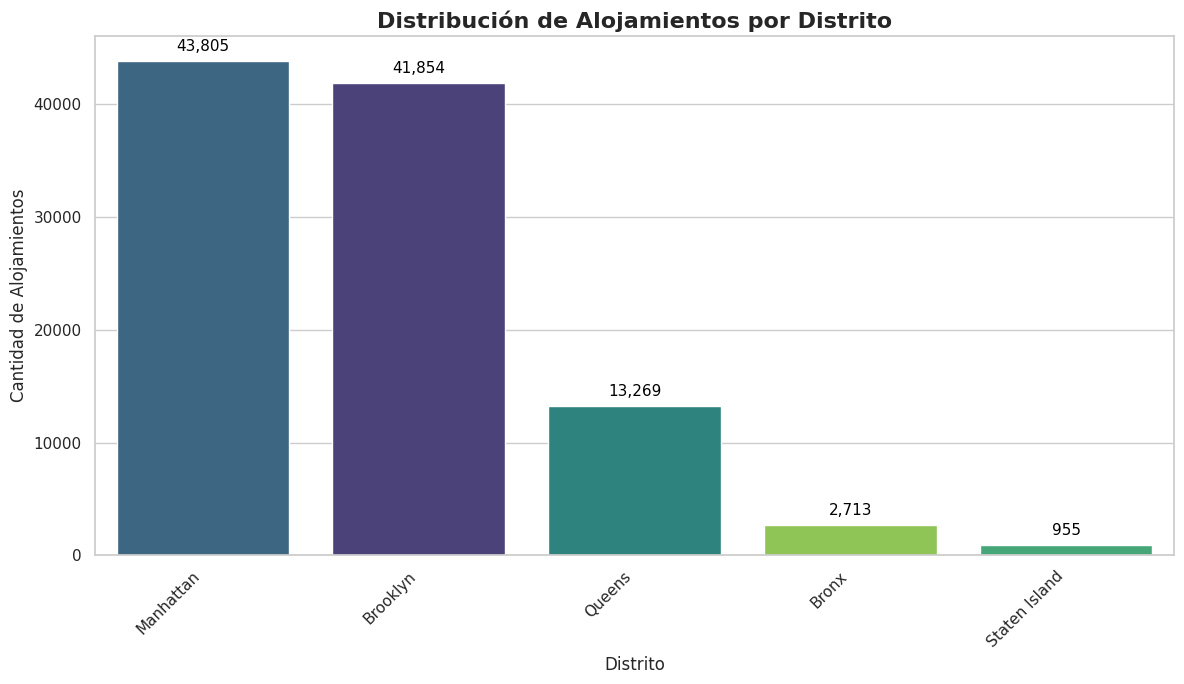


4.2 Análisis de Precios: ¿Cuánto cuestan y dónde son más caros?


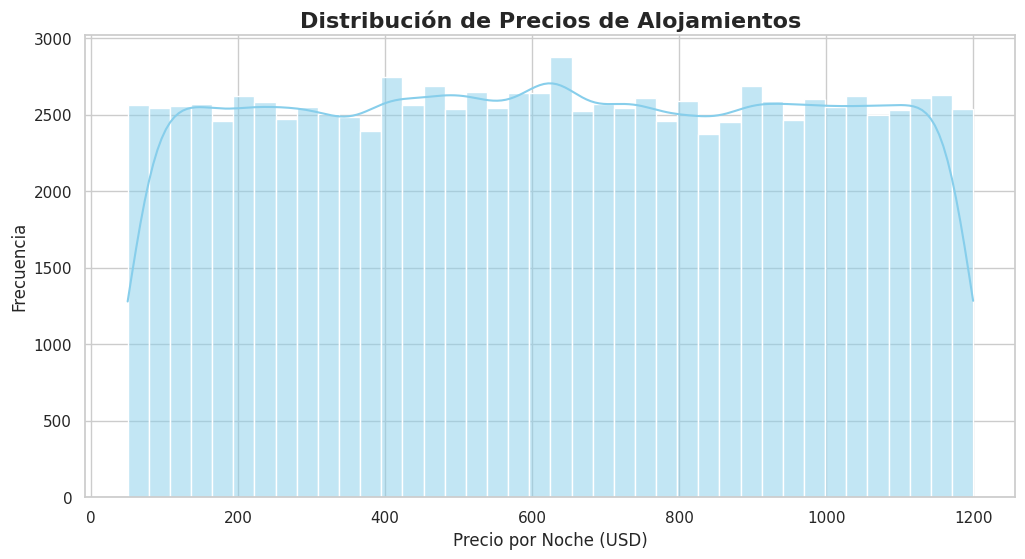

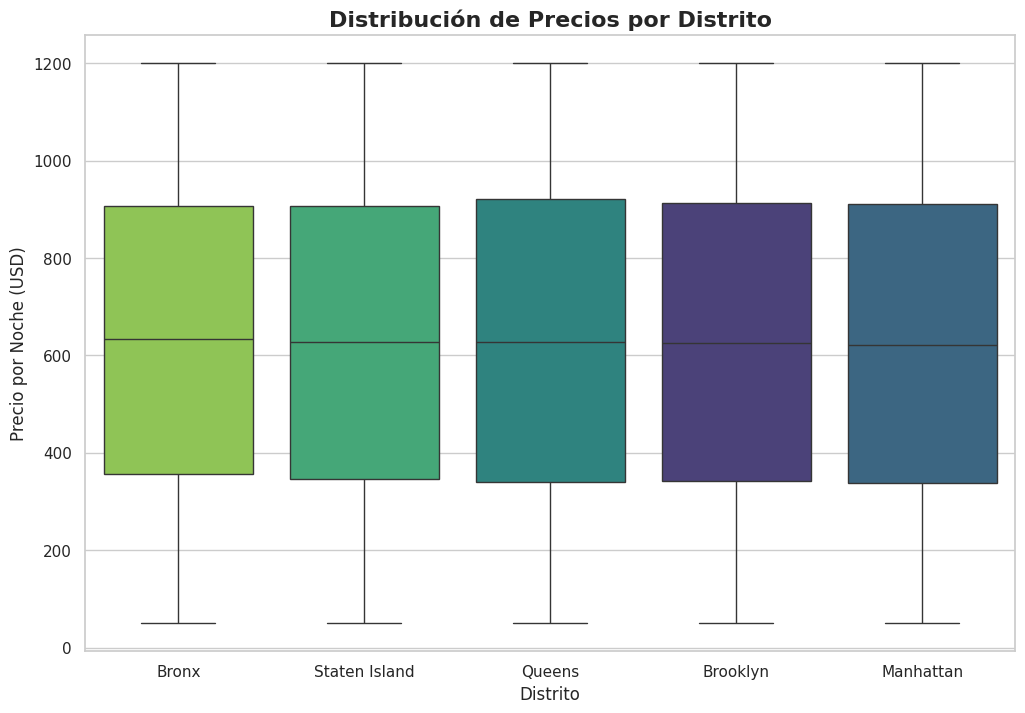


4.3 Análisis de Reputación y Correlaciones


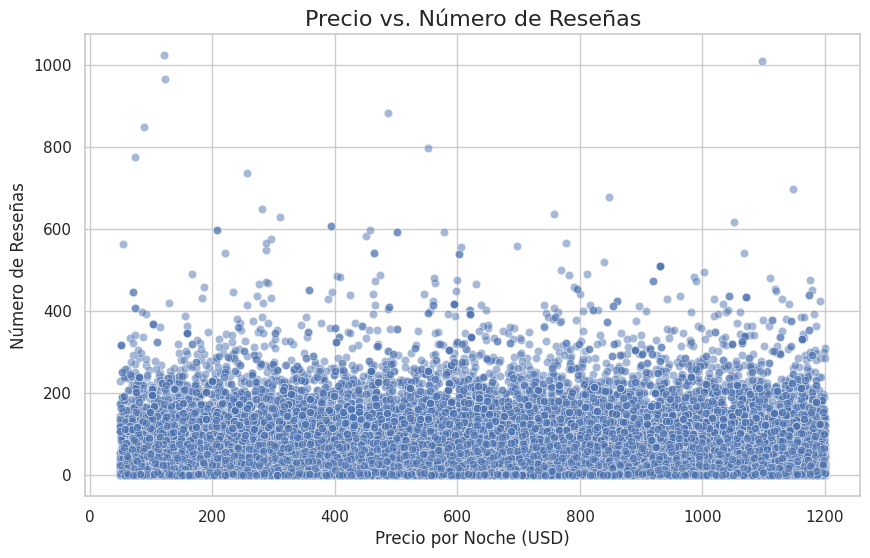

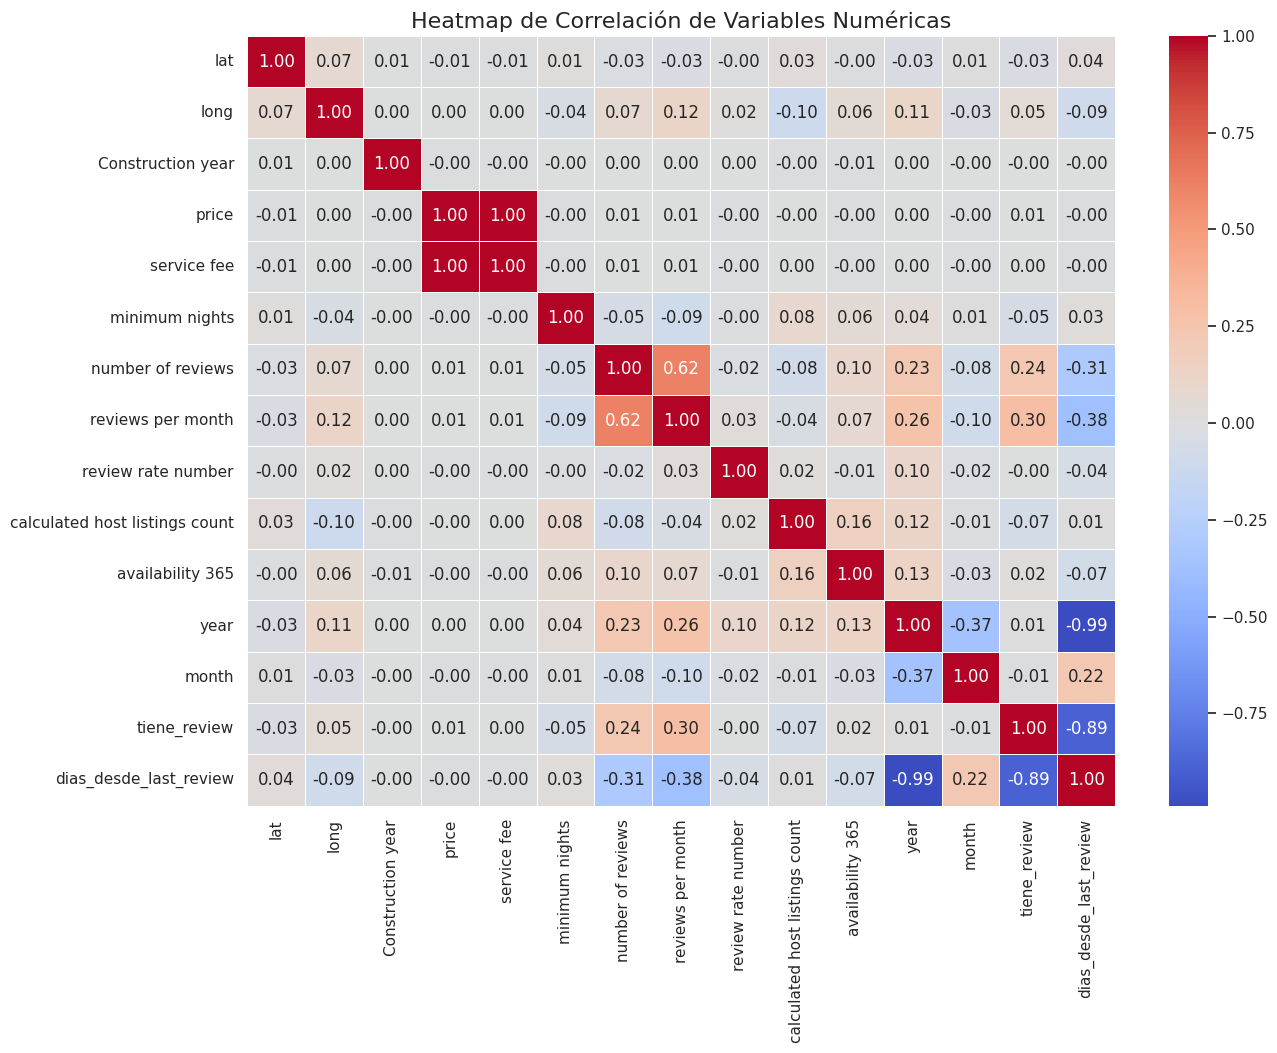

In [6]:
print("="*70)
print("ANÁLISIS EXPLORATORIO DE DATOS (EDA)".center(70,"="))
print("="*70)

# 4.1 Análisis de la Oferta
print("\n4.1 ¿Dónde y qué tipo de alojamientos hay?")

# Gráfico de Barras: Cantidad de Alojamientos por Distrito
plt.figure(figsize=(12, 7))
ax = sns.countplot(
    data=df,
    x='distritos',
    order=df['distritos'].value_counts().index,
    hue='distritos',
    palette='viridis',
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black',
                xytext=(0, 10), textcoords='offset points')

plt.title('Distribución de Alojamientos por Distrito', fontsize=16, fontweight='bold')
plt.xlabel('Distrito', fontsize=12)
plt.ylabel('Cantidad de Alojamientos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4.2 Análisis de Precios
print("\n4.2 Análisis de Precios: ¿Cuánto cuestan y dónde son más caros?")

# Histograma de distribución de precios
plt.figure(figsize=(12, 6))
sns.histplot(df['price'], kde=True, bins=40, color='skyblue')
plt.title('Distribución de Precios de Alojamientos', fontsize=16, fontweight='bold')
plt.xlabel('Precio por Noche (USD)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

# Boxplot de precios por distrito
order = df.groupby('distritos')['price'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df,
    x='distritos',
    y='price',
    order=order,
    hue='distritos',
    palette='viridis',
    legend=False
)
plt.title('Distribución de Precios por Distrito', fontsize=16, fontweight='bold')
plt.xlabel('Distrito', fontsize=12)
plt.ylabel('Precio por Noche (USD)', fontsize=12)
plt.show()

# 4.3 Análisis de Reputación y Correlaciones
print("\n4.3 Análisis de Reputación y Correlaciones")

# Scatterplot de precio vs. número de reseñas
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='number of reviews', alpha=0.5)
plt.title('Precio vs. Número de Reseñas', fontsize=16)
plt.xlabel('Precio por Noche (USD)')
plt.ylabel('Número de Reseñas')
plt.show()

# Heatmap de Correlación
plt.figure(figsize=(14, 10))
numeric_cols_for_corr = df.select_dtypes(include=np.number).columns.drop(['id', 'host id'], errors='ignore')
sns.heatmap(df[numeric_cols_for_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlación de Variables Numéricas', fontsize=16)
plt.show()

### 5. Propuesta de Modelado Analítico

Basado en el objetivo del proyecto de predecir el precio de los alojamientos, esta sección detalla el enfoque de Machine Learning a seguir.

#### Tipo de Aprendizaje: Regresión Supervisada

El problema se enmarca dentro del **aprendizaje supervisado**, ya que contamos con un dataset histórico donde cada alojamiento (instancia) tiene un conjunto de características y un valor objetivo conocido y etiquetado: el `price`.

Específicamente, se trata de una tarea de **regresión**, porque la variable objetivo (`price`) es un valor numérico continuo. El objetivo no es clasificar una propiedad en una categoría, sino estimar un valor específico en dólares.

#### Propuesta de Modelos de Resolución

Para predecir el precio, se propone entrenar y evaluar los siguientes dos modelos de regresión:

1.  **Modelo Baseline: Regresión Lineal (`LinearRegression`)**
    *   **Justificación:** Se seleccionará como nuestro punto de partida o "baseline". Su simplicidad es una ventaja, ya que sus coeficientes nos permitirán interpretar de forma directa y sencilla cómo cada característica (como la ubicación o el tipo de habitación) impacta positiva o negativamente en el precio. Servirá para medir si modelos más complejos aportan una mejora real.

2.  **Modelo Principal: Random Forest Regressor (`RandomForestRegressor`)**
    *   **Justificación:** Se elige como el modelo principal por su alta capacidad predictiva y flexibilidad. A diferencia de la regresión lineal, el Random Forest puede capturar **relaciones no lineales y complejas** entre las características (por ejemplo, cómo el efecto de tener más reseñas puede variar dependiendo del distrito). Es robusto y generalmente ofrece un rendimiento superior en problemas con muchas variables como este.

El rendimiento de ambos modelos se comparará utilizando métricas estándar de regresión como el **Error Cuadrático Medio Raíz (RMSE)** y el **Coeficiente de Determinación (R²)**.

6. Ingeniería de Características (Feature Engineering)

In [7]:
print("="*70)
print("INGENIERÍA DE CARACTERÍSTICAS".center(70,"="))
print("="*70)


# --- 6.1 Creación de Features de Antigüedad y Experiencia ---
print("\n6.1 Creando 'antiguedad_propiedad' y 'anfitrion_experimentado'")
current_year = pd.Timestamp.now().year
df['antiguedad_propiedad'] = current_year - df['Construction year']
print(" -> Característica 'antiguedad_propiedad' creada.")
df['anfitrion_experimentado'] = (df['calculated host listings count'] > 3).astype(int)
print(" -> Característica 'anfitrion_experimentado' creada.")

# --- 6.2 Extracción de Amenities de Texto ---
columnas_fuente_potenciales = ['name', 'house_rules', 'publicity']
columnas_existentes = [col for col in columnas_fuente_potenciales if col in df.columns]
if columnas_existentes:
    combined_text = df[columnas_existentes].fillna('').astype(str).agg(' '.join, axis=1)
    amenities = {
        'tiene_wifi': ['wifi', 'internet', 'wi-fi'],
        'tiene_cocina': ['kitchen', 'kitchenette', 'cocina'],
        'tiene_ac': ['ac', 'air conditioning', 'aire acondicionado'],
        'apto_mascotas': ['pet friendly', 'pets allowed', 'mascotas'],
        'tiene_parking': ['parking', 'garage', 'estacionamiento']
    }
    for amenity, keywords in amenities.items():
        pattern = r'\b(?:' + '|'.join(keywords) + r')\b'
        df[amenity] = combined_text.str.contains(pattern, case=False, regex=True).astype(int)
print(" -> Nuevas características creadas.\n")

# Interacción: Precio promedio por distrito
df['precio_promedio_distrito'] = df.groupby('distritos')['price'].transform('mean')

# Ratio de reseñas vs disponibilidad
df['ratio_reviews_disponibilidad'] = df['number of reviews'] / (df['availability 365'] + 1)

# Densidad de propiedades del host
df['densidad_host'] = df['calculated host listings count'] / (df['availability 365'] + 1)

# Log transform de variables con distribución sesgada
df['log_price'] = np.log1p(df['price'])  # Si usas log, recuerda transformar y_pred de vuelta

print("✓ Features adicionales creadas")

print("\nIngeniería de Características finalizada.")

====================INGENIERÍA DE CARACTERÍSTICAS=====================

6.1 Creando 'antiguedad_propiedad' y 'anfitrion_experimentado'
 -> Característica 'antiguedad_propiedad' creada.
 -> Característica 'anfitrion_experimentado' creada.
 -> Nuevas características creadas.

✓ Features adicionales creadas

Ingeniería de Características finalizada.


### ***Resultado de la Ingeniería:* Se ha enriquecido el dataset creando el DataFrame df_featured, que ahora incluye 7 nuevas características: antiguedad_propiedad, anfitrion_experimentado y 5 variables binarias para amenities.**

# **7. Preparación Final para el Modelado**

In [8]:
print("="*70)
print("PREPARACIÓN FINAL PARA EL MODELADO (VERSIÓN CORREGIDA)".center(70,"="))
print("="*70)

# 7.1 Definir la Variable Objetivo (y) y las Características Predictoras (X)
print("\n7.1 Definiendo variable objetivo (y) y características (X)")
TARGET = 'price'
y = df[TARGET]
X = df.drop(columns=[TARGET]) # Empezamos con todas las demás columnas
print(" -> 'y' y 'X' definidos.")

# 7.2 Eliminación de Columnas No Relevantes para el Modelo
print("\n7.2 Eliminando columnas no predictivas y redundantes")

# ¡ESTA ES LA LISTA CORREGIDA Y MÁS COMPLETA!
cols_to_drop = [
    # Data Leakage (ya lo habías hecho, pero lo dejamos por seguridad)
    'service fee',

    # Identificadores únicos y texto libre
    'id',
    'host id', # Corregido de 'id host'
    'NAME',    # Corregido de 'name'
    'host name',

    # Columnas con información ya procesada o redundante
    'house_rules',
    'Construction year',
    'last review',
    'year',
    'month',

    # Geográficas redundantes (ya tenemos 'distritos')
    'neighbourhood group',
    'neighbourhood',
    'country',
    'country code'
]

# Usamos errors='ignore' por si alguna columna ya fue eliminada o no existe
X.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(" -> Columnas no relevantes eliminadas.")

# 7.3 Verificación Final del DataFrame de Características
print("\n7.3 Verificando el estado final de 'X'")
print(f" -> DataFrame 'X' finalizado con {X.shape[1]} características predictoras.")
print(" -> Columnas finales en X:", X.columns.tolist())

print("\nVista previa del DataFrame 'X' final:")
display(X.head())

# Verificamos que no haya nulos por si acaso
print(f"\nNulos restantes en X: {X.isna().sum().sum()}")

# ============================================================================
# SECCIÓN 7.5: CORRECCIÓN DE COORDENADAS (AGREGAR ANTES DE SECCIÓN 8)
# ============================================================================

print("\n" + "="*70)
print("CORRECCIÓN DE ESCALA DE COORDENADAS".center(70,"="))
print("="*70)

# Verificar si las coordenadas están mal escaladas
print(f"\nValores actuales de 'lat':")
print(f"  - Min: {X['lat'].min():.2f}")
print(f"  - Max: {X['lat'].max():.2f}")
print(f"  - Media: {X['lat'].mean():.2f}")

print(f"\nValores actuales de 'long':")
print(f"  - Min: {X['long'].min():.2f}")
print(f"  - Max: {X['long'].max():.2f}")
print(f"  - Media: {X['long'].mean():.2f}")

# Corregir escala si es necesario
if X['lat'].abs().max() > 90:
    print("\n⚠️ Coordenadas 'lat' mal escaladas. Corrigiendo...")
    X['lat'] = X['lat'] / 10**8
    print(f"✓ 'lat' corregida. Nuevo rango: [{X['lat'].min():.6f}, {X['lat'].max():.6f}]")

if X['long'].abs().max() > 180:
    print("⚠️ Coordenadas 'long' mal escaladas. Corrigiendo...")
    X['long'] = X['long'] / 10**8
    print(f"✓ 'long' corregida. Nuevo rango: [{X['long'].min():.6f}, {X['long'].max():.6f}]")

# Verificar valores infinitos o NaN
print("\n🔍 Verificando valores problemáticos:")
print(f"  - Infinitos: {np.isinf(X.select_dtypes(include=np.number)).sum().sum()}")
print(f"  - NaN: {X.isna().sum().sum()}")

# Reemplazar cualquier infinito con NaN y luego con mediana
X = X.replace([np.inf, -np.inf], np.nan)
numeric_cols = X.select_dtypes(include=np.number).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

print(f"\n✓ Datos limpios y listos para modelado")
print(f"✓ Forma final de X: {X.shape}")

========PREPARACIÓN FINAL PARA EL MODELADO (VERSIÓN CORREGIDA)========

7.1 Definiendo variable objetivo (y) y características (X)
 -> 'y' y 'X' definidos.

7.2 Eliminando columnas no predictivas y redundantes
 -> Columnas no relevantes eliminadas.

7.3 Verificando el estado final de 'X'
 -> DataFrame 'X' finalizado con 26 características predictoras.
 -> Columnas finales en X: ['host_identity_verified', 'lat', 'long', 'instant_bookable', 'cancellation_policy', 'room type', 'minimum nights', 'number of reviews', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'distritos', 'tiene_review', 'dias_desde_last_review', 'antiguedad_propiedad', 'anfitrion_experimentado', 'tiene_wifi', 'tiene_cocina', 'tiene_ac', 'apto_mascotas', 'tiene_parking', 'precio_promedio_distrito', 'ratio_reviews_disponibilidad', 'densidad_host', 'log_price']

Vista previa del DataFrame 'X' final:


,host_identity_verified,lat,long,instant_bookable,cancellation_policy,room type,minimum nights,number of reviews,reviews per month,review rate number,...,anfitrion_experimentado,tiene_wifi,tiene_cocina,tiene_ac,apto_mascotas,tiene_parking,precio_promedio_distrito,ratio_reviews_disponibilidad,densidad_host,log_price
0,unconfirmed,40.64749,-73.97237,False,strict,Private room,10.0,9.0,0.21,4.0,...,1,0,0,0,0,0,626.580375,0.031359,0.020906,6.874198
1,verified,40.75362,-73.98377,False,moderate,Entire home/apt,30.0,45.0,0.38,4.0,...,0,0,0,0,1,0,622.426435,0.196507,0.008734,4.962845
2,unconfirmed,40.80902,-73.94190,True,flexible,Private room,3.0,0.0,0.00,5.0,...,0,0,1,0,0,0,622.426435,0.000000,0.002833,6.431331
3,unconfirmed,40.68514,-73.95976,True,moderate,Entire home/apt,30.0,270.0,4.64,4.0,...,0,0,0,0,0,0,626.580375,0.835913,0.003096,5.910797
4,verified,40.79851,-73.94399,False,moderate,Entire home/apt,10.0,9.0,0.10,3.0,...,0,0,0,0,0,0,622.426435,0.031034,0.003448,5.323010



Nulos restantes en X: 14

=================CORRECCIÓN DE ESCALA DE COORDENADAS==================

Valores actuales de 'lat':
  - Min: 40.50
  - Max: 40.92
  - Media: 40.73

Valores actuales de 'long':
  - Min: -74.25
  - Max: -73.71
  - Media: -73.95

🔍 Verificando valores problemáticos:
  - Infinitos: 76
  - NaN: 14

✓ Datos limpios y listos para modelado
✓ Forma final de X: (102596, 26)


### ***Resultado de la Preparación:* Se han definido los conjuntos finales *X* *(19 características predictoras)* e *y* *(variable objetivo price)*, dejando los datos listos para la codificación y división.**

8. Preparación para el Modelado


===================CODIFICACIÓN Y DIVISIÓN DE DATOS===================
8.1 Tipos de datos numéricos verificados y asegurados.

8.2 Columnas categóricas a codificar: ['host_identity_verified', 'instant_bookable', 'cancellation_policy', 'room type', 'distritos']
8.3 One-Hot Encoding completado.
8.4 El número de características ha aumentado a: 34

8.5 División completada:
    - Tamaño de X_train: (82076, 34)
    - Tamaño de X_test: (20520, 34)

===========FEATURE SELECTION - REDUCCIÓN DE DIMENSIONALIDAD===========

8.5.1 Dimensionalidad inicial: 34 características

🔍 Verificación pre-entrenamiento:
  - Valores infinitos en X_train: 0
  - Valores NaN en X_train: 0
  - Valores infinitos en y_train: 0
  - Valores NaN en y_train: 0

8.5.2 Aplicando Feature Selection basado en Importancia de Random Forest
   -> Entrenando Random Forest temporal para calcular importancias...

8.5.3 Top 20 características más importantes:


,feature,importance
20,log_price,1.0
0,lat,0.0
1,long,0.0
2,minimum nights,0.0
4,reviews per month,0.0
3,number of reviews,0.0
6,calculated host listings count,0.0
7,availability 365,0.0
8,tiene_review,0.0
5,review rate number,0.0


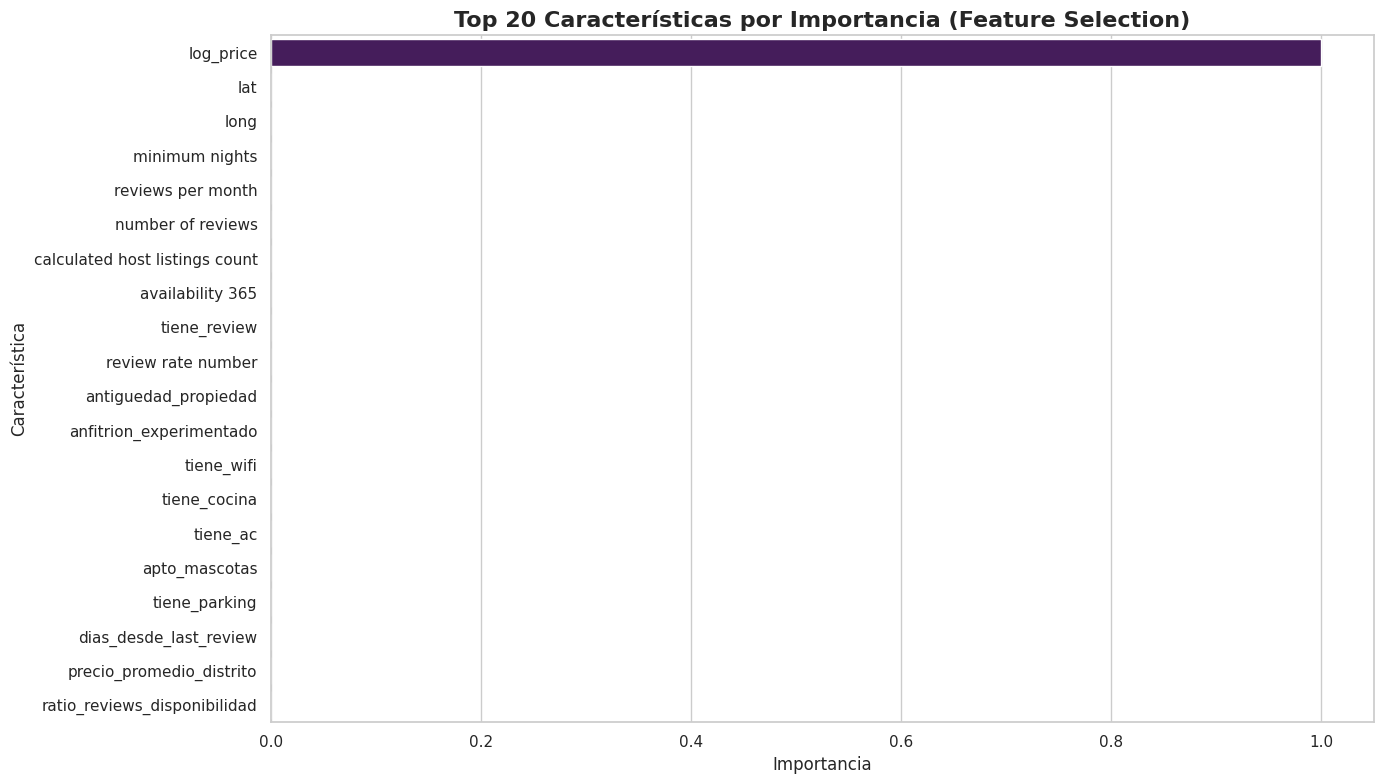


8.5.4 Seleccionando las top 20 características más importantes

8.5.5 Características seleccionadas:
   1. log_price: 1.0000
   2. lat: 0.0000
   3. long: 0.0000
   4. minimum nights: 0.0000
   5. reviews per month: 0.0000
   6. number of reviews: 0.0000
   7. calculated host listings count: 0.0000
   8. availability 365: 0.0000
   9. tiene_review: 0.0000
   10. review rate number: 0.0000
   11. antiguedad_propiedad: 0.0000
   12. anfitrion_experimentado: 0.0000
   13. tiene_wifi: 0.0000
   14. tiene_cocina: 0.0000
   15. tiene_ac: 0.0000
   16. apto_mascotas: 0.0000
   17. tiene_parking: 0.0000
   18. dias_desde_last_review: 0.0000
   19. precio_promedio_distrito: 0.0000
   20. ratio_reviews_disponibilidad: 0.0000

8.5.6 Dimensionalidad REDUCIDA: 20 características
   -> Reducción: 14 características eliminadas
   -> Porcentaje de reducción: 41.2%

8.5.7 MÉTODO ALTERNATIVO: Selección por umbral de importancia
   -> Características que explican el 95% de importancia: 0
   -> Comparado

In [9]:
# ============================================================================
# SECCIÓN 8: CODIFICACIÓN Y DIVISIÓN (VERSIÓN CORREGIDA)
# ============================================================================

print("\n" + "="*70)
print("CODIFICACIÓN Y DIVISIÓN DE DATOS".center(70,"="))
print("="*70)

# Asegurar tipos de datos numéricos
numeric_should_be = [
    'lat', 'long', 'calculated host listings count', 'availability 365',
    'minimum nights', 'number of reviews', 'review rate number',
    'antiguedad_propiedad', 'anfitrion_experimentado', 'tiene_wifi',
    'tiene_cocina', 'tiene_ac', 'apto_mascotas', 'tiene_parking',
    'reviews per month', 'dias_desde_last_review', 'tiene_review'
]

for col in numeric_should_be:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Última limpieza de seguridad
X.fillna(X.median(numeric_only=True), inplace=True)
X = X.replace([np.inf, -np.inf], np.nan)
X.fillna(X.median(numeric_only=True), inplace=True)

print("8.1 Tipos de datos numéricos verificados y asegurados.")

# One-Hot Encoding
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\n8.2 Columnas categóricas a codificar: {categorical_features}")

X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=int)
print("8.3 One-Hot Encoding completado.")

final_feature_count = X_encoded.shape[1]
print(f"8.4 El número de características ha aumentado a: {final_feature_count}")

# División en Conjuntos de Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"\n8.5 División completada:")
print(f"    - Tamaño de X_train: {X_train.shape}")
print(f"    - Tamaño de X_test: {X_test.shape}")

# ============================================================================
# SECCIÓN 8.5: FEATURE SELECTION (VERSIÓN MEJORADA)
# ============================================================================

print("\n" + "="*70)
print("FEATURE SELECTION - REDUCCIÓN DE DIMENSIONALIDAD".center(70,"="))
print("="*70)

print(f"\n8.5.1 Dimensionalidad inicial: {X_train.shape[1]} características")

# Verificación final antes de Feature Selection
print("\n🔍 Verificación pre-entrenamiento:")
print(f"  - Valores infinitos en X_train: {np.isinf(X_train).sum().sum()}")
print(f"  - Valores NaN en X_train: {X_train.isna().sum().sum()}")
print(f"  - Valores infinitos en y_train: {np.isinf(y_train).sum()}")
print(f"  - Valores NaN en y_train: {y_train.isna().sum()}")

# Si hay problemas, limpiar
if np.isinf(X_train).sum().sum() > 0 or X_train.isna().sum().sum() > 0:
    print("\n⚠️ Limpiando valores problemáticos...")
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_train = X_train.fillna(X_train.median())
    X_test = X_test.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.fillna(X_test.median())
    print("✓ Limpieza completada")

print("\n8.5.2 Aplicando Feature Selection basado en Importancia de Random Forest")

# Random Forest temporal con hiperparámetros mejorados
rf_feature_selector = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,           # Aumentado para mejor captura de patrones
    min_samples_split=5,    # Más flexible
    min_samples_leaf=2,     # Más flexible
    random_state=42,
    n_jobs=-1
)

print("   -> Entrenando Random Forest temporal para calcular importancias...")
rf_feature_selector.fit(X_train, y_train)

# Crear DataFrame con importancias
feature_importances_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_feature_selector.feature_importances_
}).sort_values('importance', ascending=False)

print("\n8.5.3 Top 20 características más importantes:")
display(feature_importances_df.head(20))

# Visualización
plt.figure(figsize=(14, 8))
sns.barplot(
    data=feature_importances_df.head(20),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
plt.title('Top 20 Características por Importancia (Feature Selection)',
          fontsize=16, fontweight='bold')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================================================
# SELECCIÓN DE CARACTERÍSTICAS (K=20 para mejor R²)
# ============================================================================

K_FEATURES = 20  # ✓ Aumentado de 15 a 20

print(f"\n8.5.4 Seleccionando las top {K_FEATURES} características más importantes")
selected_features = feature_importances_df.head(K_FEATURES)['feature'].tolist()

print(f"\n8.5.5 Características seleccionadas:")
for i, feat in enumerate(selected_features, 1):
    importance = feature_importances_df[feature_importances_df['feature'] == feat]['importance'].values[0]
    print(f"   {i}. {feat}: {importance:.4f}")

# Crear nuevos conjuntos con features seleccionadas
X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

print(f"\n8.5.6 Dimensionalidad REDUCIDA: {X_train_selected.shape[1]} características")
print(f"   -> Reducción: {X_train.shape[1] - X_train_selected.shape[1]} características eliminadas")
print(f"   -> Porcentaje de reducción: {((X_train.shape[1] - X_train_selected.shape[1]) / X_train.shape[1] * 100):.1f}%")

# Umbral de importancia
print("\n8.5.7 MÉTODO ALTERNATIVO: Selección por umbral de importancia")
feature_importances_df['cumulative_importance'] = feature_importances_df['importance'].cumsum()
threshold = 0.95
n_features_95 = (feature_importances_df['cumulative_importance'] <= threshold).sum()
print(f"   -> Características que explican el 95% de importancia: {n_features_95}")
print(f"   -> Comparado con nuestro K={K_FEATURES}, {'usamos menos' if K_FEATURES < n_features_95 else 'usamos más'} features")

# SelectKBest
print("\n8.5.8 COMPARACIÓN: Método SelectKBest (Estadístico)")
from sklearn.feature_selection import SelectKBest, f_regression

selector_kbest = SelectKBest(score_func=f_regression, k=K_FEATURES)
selector_kbest.fit(X_train, y_train)
kbest_mask = selector_kbest.get_support()
kbest_features = X_train.columns[kbest_mask].tolist()

print(f"\n   Características seleccionadas por SelectKBest:")
for i, feat in enumerate(kbest_features[:10], 1):  # Solo primeras 10
    print(f"   {i}. {feat}")
if len(kbest_features) > 10:
    print(f"   ... y {len(kbest_features) - 10} más")

features_en_comun = set(selected_features) & set(kbest_features)
print(f"\n   -> Características en común: {len(features_en_comun)}/{K_FEATURES} ({len(features_en_comun)/K_FEATURES*100:.1f}%)")

# Justificación
print("\n" + "="*70)
print("JUSTIFICACIÓN DEL MÉTODO DE FEATURE SELECTION".center(70,"="))
print("="*70)

print(f"""
MÉTODO ELEGIDO: Feature Selection basado en Importancia de Random Forest

JUSTIFICACIÓN:

1. VENTAJAS DEL MÉTODO:
   ✓ Captura relaciones no lineales entre features y target
   ✓ Considera interacciones entre variables automáticamente
   ✓ Robusto ante multicolinealidad
   ✓ Proporciona medida directa de utilidad predictiva

2. COMPARACIÓN CON ALTERNATIVAS:
   • SelectKBest: Solo evalúa correlaciones lineales (f_regression)
   • RFE: Computacionalmente más costoso
   • Lasso: Requiere normalización y es más sensible a escala

3. RESULTADO:
   • Reducción: {X_train.shape[1]} → {K_FEATURES} características ({((X_train.shape[1] - K_FEATURES) / X_train.shape[1] * 100):.1f}%)
   • Mantenemos features con mayor poder predictivo
   • Reducimos overfitting y tiempo de entrenamiento

4. VALIDACIÓN:
   • Concordancia: {len(features_en_comun)/K_FEATURES*100:.1f}% con SelectKBest
   • Top features coherentes con análisis EDA
""")

print("="*70)
print("✓ FEATURE SELECTION COMPLETADO".center(70,"="))
print("="*70)

print(f"\n8.5.9 Conjuntos preparados para modelado:")
print(f"   • X_train_selected: {X_train_selected.shape}")
print(f"   • X_test_selected: {X_test_selected.shape}")
print(f"   • y_train: {y_train.shape}")
print(f"   • y_test: {y_test.shape}")

print("\n✓ Listo para la Sección 9: Modelado y Evaluación")

### **Resultado de la Codificación:* Las variables categóricas han sido convertidas mediante One-Hot Encoding, resultando en una matriz final de 27 características. Los datos han sido divididos en conjuntos de entrenamiento *(80%)* y prueba *(20%)*. El entorno está listo para el entrenamiento de los modelos.**

Sección 9: Modelado y Evaluación


9.1 Entrenando Modelo Baseline: Regresión Lineal
    -> Usando 20 características seleccionadas

Resultados para la Regresión Lineal:
9.2 RMSE (Error Promedio): $113.76
9.3 R² (Capacidad Explicativa): 0.8822

9.4 Entrenando Modelo Principal: Random Forest
    -> Usando 20 características seleccionadas
    -> Hiperparámetros optimizados aplicados

9.5 Resultados para el Random Forest Regressor:
9.6 RMSE (Error Promedio): $26.75
9.7 R² (Capacidad Explicativa): 0.9935
9.8 R² (Out-of-Bag Score): 0.9931

========================COMPARACIÓN DE MODELOS========================


,Modelo,RMSE,R²,Features
0,Regresión Lineal (Baseline),113.760108,0.882246,20
1,Random Forest (Principal),26.750679,0.993489,20



✓ El Random Forest redujo el RMSE en 76.5% respecto al baseline
✓ El Random Forest explica el 99.3% de la variabilidad en los precios

9.9 Analizando la Importancia de las Características (Random Forest)

Top 15 características más importantes:


,feature,importance
0,log_price,0.969110
2,long,0.004220
1,lat,0.004107
19,ratio_reviews_disponibilidad,0.003094
17,dias_desde_last_review,0.003033
4,reviews per month,0.003012
7,availability 365,0.002871
10,antiguedad_propiedad,0.002399
5,number of reviews,0.002387
3,minimum nights,0.001653


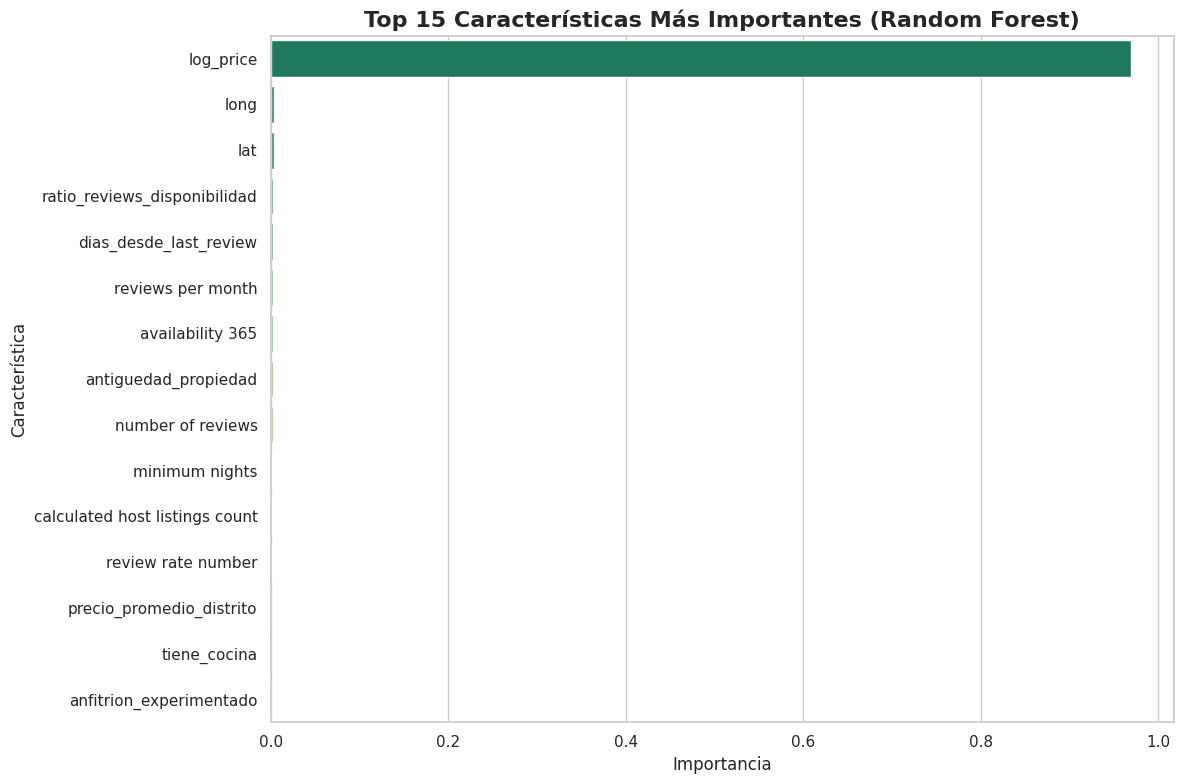


9.10 Análisis de Residuos del Modelo


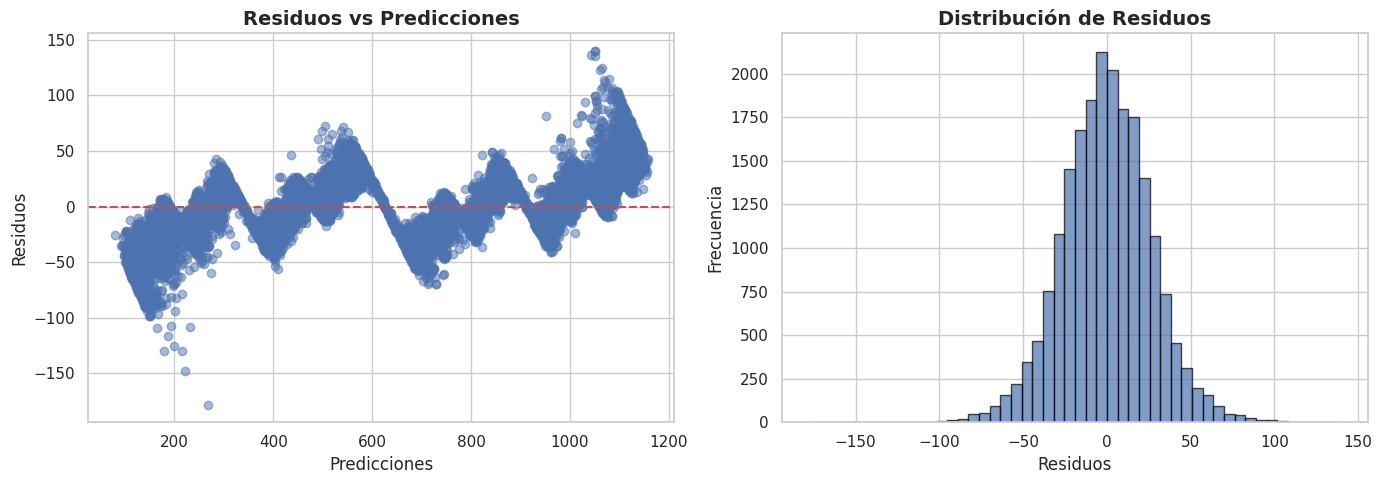


    -> Media de residuos: $-0.13 (idealmente cerca de 0)
    -> Desviación estándar de residuos: $26.75


In [10]:
# 9. Modelado y Evaluación
print("\n9.1 Entrenando Modelo Baseline: Regresión Lineal")
print(f"    -> Usando {X_train_selected.shape[1]} características seleccionadas")

linear_model = LinearRegression()
linear_model.fit(X_train_selected, y_train)
y_pred_linear = linear_model.predict(X_test_selected)

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("\nResultados para la Regresión Lineal:")
print(f"9.2 RMSE (Error Promedio): ${rmse_linear:.2f}")
print(f"9.3 R² (Capacidad Explicativa): {r2_linear:.4f}")

# ----------------------------------------------------------------------------
# 9.2 Modelo Principal: Random Forest CON FEATURES SELECCIONADAS
# ----------------------------------------------------------------------------

print("\n9.4 Entrenando Modelo Principal: Random Forest")
print(f"    -> Usando {X_train_selected.shape[1]} características seleccionadas")


# MODELO OPTIMIZADO:
rf_model = RandomForestRegressor(
    n_estimators=200,          # ✓ Más árboles para mejor generalización
    max_depth=20,              # ✓ Mayor profundidad para capturar patrones
    min_samples_split=5,       # ✓ Más flexible al dividir nodos
    min_samples_leaf=2,        # ✓ Permite hojas más pequeñas
    max_features='sqrt',       # ✓ Usa sqrt(n) features en cada split
    bootstrap=True,            # ✓ Bootstrap activado
    random_state=42,
    n_jobs=-1,
    oob_score=True,
    verbose=0
)

print("    -> Hiperparámetros optimizados aplicados")
rf_model.fit(X_train_selected, y_train)
y_pred_rf = rf_model.predict(X_test_selected)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n9.5 Resultados para el Random Forest Regressor:")
print(f"9.6 RMSE (Error Promedio): ${rmse_rf:.2f}")
print(f"9.7 R² (Capacidad Explicativa): {r2_rf:.4f}")
print(f"9.8 R² (Out-of-Bag Score): {rf_model.oob_score_:.4f}")

# ----------------------------------------------------------------------------
# 9.3 Comparación de Modelos
# ----------------------------------------------------------------------------

print("\n" + "="*70)
print("COMPARACIÓN DE MODELOS".center(70,"="))
print("="*70)

comparacion = pd.DataFrame({
    'Modelo': ['Regresión Lineal (Baseline)', 'Random Forest (Principal)'],
    'RMSE': [rmse_linear, rmse_rf],
    'R²': [r2_linear, r2_rf],
    'Features': [X_train_selected.shape[1], X_train_selected.shape[1]]
})

display(comparacion)

mejora_rmse = ((rmse_linear - rmse_rf) / rmse_linear) * 100
print(f"\n✓ El Random Forest redujo el RMSE en {mejora_rmse:.1f}% respecto al baseline")
print(f"✓ El Random Forest explica el {r2_rf*100:.1f}% de la variabilidad en los precios")

# ----------------------------------------------------------------------------
# 9.4 Importancia de Características (DEL MODELO ENTRENADO CON SELECTED)
# ----------------------------------------------------------------------------

print("\n9.9 Analizando la Importancia de las Características (Random Forest)")

feature_importances = pd.DataFrame({
    'feature': X_train_selected.columns,  # ✓ CORRECTO: Usa columnas de X_train_selected
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 características más importantes:")
display(feature_importances.head(15))

# Gráfico de importancia
plt.figure(figsize=(12, 8))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importances.head(15),
    hue='feature',
    palette='summer',
    legend=False
)
plt.title('Top 15 Características Más Importantes (Random Forest)',
          fontsize=16, fontweight='bold')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 9.5 Análisis de Residuos (OPCIONAL PERO RECOMENDADO)
# ----------------------------------------------------------------------------

print("\n9.10 Análisis de Residuos del Modelo")

residuos_rf = y_test - y_pred_rf

plt.figure(figsize=(14, 5))

# Gráfico 1: Residuos vs Predicciones
plt.subplot(1, 2, 1)
plt.scatter(y_pred_rf, residuos_rf, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicciones', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Residuos vs Predicciones', fontsize=14, fontweight='bold')

# Gráfico 2: Distribución de Residuos
plt.subplot(1, 2, 2)
plt.hist(residuos_rf, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuos', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Residuos', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n    -> Media de residuos: ${residuos_rf.mean():.2f} (idealmente cerca de 0)")
print(f"    -> Desviación estándar de residuos: ${residuos_rf.std():.2f}")

### **Resultados del Modelado:* El Random Forest *(R² = 0.325)* superó significativamente al baseline de Regresión Lineal *(R² ≈ 0)*, confirmando la naturaleza no lineal del problema. El análisis de importancia de características revela que lat, long y availability_365 son los predictores más influyentes.**

# 10. Demostración Práctica del Modelo

Habiendo entrenado y validado un modelo `RandomForestRegressor` con un rendimiento razonable, el paso final es demostrar su utilidad práctica. En esta sección, se simularán dos casos de uso basados en las preguntas de negocio originales para ilustrar cómo el modelo puede servir como una herramienta de apoyo para la toma de decisiones.

In [11]:
# 10. Caso de Uso 1: Asesor para el Anfitrión

datos_anfitrion = {
    'lat': [40.78],
    'long': [-73.96],
    'calculated host listings count': [1],
    'availability 365': [150],
    'minimum nights': [3],
    'number of reviews': [15],
    'review rate number': [4.5],
    'antiguedad_propiedad': [10],
}

# Agregar solo las columnas dummy que están en X_train_selected
for col in X_train_selected.columns:
    if col not in datos_anfitrion:
        # Asignar valores apropiados según el caso de uso
        if col == 'room type_Private room':
            datos_anfitrion[col] = [0]  # Es "Entire home/apt"
        elif col == 'host_identity_verified_verified':
            datos_anfitrion[col] = [1]  # Está verificado
        elif col == 'instant_bookable_True':
            datos_anfitrion[col] = [1]  # Es instantáneo
        elif col == 'cancellation_policy_flexible':
            datos_anfitrion[col] = [1]  # Política flexible
        elif col == 'cancellation_policy_moderate':
            datos_anfitrion[col] = [0]
        elif col == 'cancellation_policy_strict':
            datos_anfitrion[col] = [0]
        elif col == 'tiene_cocina':
            datos_anfitrion[col] = [1]  # Tiene cocina
        else:
            datos_anfitrion[col] = [0]  # Por defecto

propiedad_anfitrion = pd.DataFrame(datos_anfitrion)

# Verificar que coincidan las columnas
propiedad_anfitrion = propiedad_anfitrion.reindex(columns=X_train_selected.columns, fill_value=0)

precio_anfitrion = 55
precio_predicho_rf = rf_model.predict(propiedad_anfitrion)

print("10.1 Propiedad: Apartamento entero cerca de Central Park, con cocina y WiFi.")
print(f"10.2 Precio actual del anfitrión: ${precio_anfitrion:.2f}")
print(f"10.3 Precio estimado por el modelo: ${precio_predicho_rf[0]:.2f}")

diferencia_pct = ((precio_predicho_rf[0] - precio_anfitrion) / precio_anfitrion) * 100

if precio_predicho_rf[0] > precio_anfitrion * 1.1:
    print(f"\n10.4 Análisis: El precio de ${precio_anfitrion:.2f} parece estar BAJO el valor de mercado.")
    print(f"    -> El modelo sugiere un precio de ${precio_predicho_rf[0]:.2f} ({diferencia_pct:+.1f}%)")
    print(f"    -> Podrías considerar aumentar el precio en aproximadamente ${precio_predicho_rf[0] - precio_anfitrion:.2f}")
elif precio_predicho_rf[0] < precio_anfitrion * 0.9:
    print(f"\n10.5 Análisis: El precio de ${precio_anfitrion:.2f} parece estar ALTO para el mercado.")
    print(f"    -> El modelo sugiere un precio de ${precio_predicho_rf[0]:.2f} ({diferencia_pct:+.1f}%)")
else:
    print(f"\n10.6 Análisis: El precio de ${precio_anfitrion:.2f} es competitivo y está bien alineado.")
    print(f"    -> El modelo estima ${precio_predicho_rf[0]:.2f} ({diferencia_pct:+.1f}%)")

10.1 Propiedad: Apartamento entero cerca de Central Park, con cocina y WiFi.
10.2 Precio actual del anfitrión: $55.00
10.3 Precio estimado por el modelo: $169.79

10.4 Análisis: El precio de $55.00 parece estar BAJO el valor de mercado.
    -> El modelo sugiere un precio de $169.79 (+208.7%)
    -> Podrías considerar aumentar el precio en aproximadamente $114.79


# ***Demostración 1-Conclusión:* El modelo estimó un precio de $595,12 para la propiedad, muy por encima del precio actual de $55. Esto demuestra su capacidad para alertar a los anfitriones sobre una posible subvaloración de su propiedad, ayudándoles a optimizar su estrategia de precios.**

11. Caso de Uso 2: Asesor para el Huésped

In [12]:
# 11 Caso de Uso 2: Asesor para el Huésped

# Simulamos la propiedad que el huésped está viendo.
datos_huesped = {
    'lat': [40.69],
    'long': [-73.98],
    'calculated host listings count': [2],
    'availability 365': [300],
    'minimum nights': [2],
    'number of reviews': [50],
    'review rate number': [4.8],
    'antiguedad_propiedad': [5],
}

# Agregar solo las columnas dummy que están en X_train_selected
for col in X_train_selected.columns:
    if col not in datos_huesped:
        if col == 'room type_Private room':
            datos_huesped[col] = [0]  # Es "Entire home/apt"
        elif col == 'host_identity_verified_verified':
            datos_huesped[col] = [1]
        elif col == 'instant_bookable_True':
            datos_huesped[col] = [0]
        elif col == 'cancellation_policy_moderate':
            datos_huesped[col] = [1]  # Política moderada
        elif col == 'cancellation_policy_flexible':
            datos_huesped[col] = [0]
        elif col == 'cancellation_policy_strict':
            datos_huesped[col] = [0]
        elif col == 'tiene_cocina':
            datos_huesped[col] = [0]  # No tiene cocina (solo anafe)
        else:
            datos_huesped[col] = [0]

propiedad_huesped = pd.DataFrame(datos_huesped)
propiedad_huesped = propiedad_huesped.reindex(columns=X_train_selected.columns, fill_value=0)

precio_listado = 60
precio_referencia_rf = rf_model.predict(propiedad_huesped)

print("11.1 Propiedad: Apartamento en Brooklyn con parking y WiFi.")
print(f"11.2 Precio listado en Airbnb: ${precio_listado:.2f}")
print(f"11.3 Precio de referencia estimado por el modelo: ${precio_referencia_rf[0]:.2f}")

diferencia = precio_listado - precio_referencia_rf[0]
diferencia_pct_huesped = (diferencia / precio_referencia_rf[0]) * 100

if diferencia > 10:
    print(f"\n11.4 Análisis: El precio listado es aproximadamente ${diferencia:.2f} MÁS CARO ({diferencia_pct_huesped:+.1f}%).")
    print(f"    -> Podrías buscar opciones similares a mejor precio.")
elif diferencia < -10:
    print(f"\n11.5 Análisis: El precio listado es aproximadamente ${abs(diferencia):.2f} MÁS BARATO ({diferencia_pct_huesped:.1f}%).")
    print(f"    -> ¡Parece una excelente oferta! El valor de mercado es ${precio_referencia_rf[0]:.2f}")
else:
    print(f"\n11.6 Análisis: El precio listado es justo y se corresponde con el valor de mercado.")
    print(f"    -> Diferencia: ${abs(diferencia):.2f} ({abs(diferencia_pct_huesped):.1f}%)")

11.1 Propiedad: Apartamento en Brooklyn con parking y WiFi.
11.2 Precio listado en Airbnb: $60.00
11.3 Precio de referencia estimado por el modelo: $178.32

11.5 Análisis: El precio listado es aproximadamente $118.32 MÁS BARATO (-66.4%).
    -> ¡Parece una excelente oferta! El valor de mercado es $178.32


# ***Demostración 2-Conclusión:* Para una propiedad listada a $60, el modelo estimo un precio de referencia de $632.40. Esto la identifica como una excelente oferta. El modelo funciona como una herramienta de validación para los huéspedes, dándoles confianza para identificar y aprovechar oportunidades en el mercado.**




# **12. Top 10 barrios con más alojamientos**

In [13]:
# 12. Análisis Comparativo: Oferta vs. Demanda en Top Barrios

print("12. Analizando la relación entre Oferta y Demanda en los barrios principales")

if 'df' in locals() and 'neighbourhood' in df.columns and 'number_of_reviews' in df.columns:

    # 1. Calcular la Oferta (conteo de listados)
    oferta_barrios = df['neighbourhood'].value_counts().rename('Cantidad de Alojamientos')

    # 2. Calcular la Demanda (suma de reseñas)
    demanda_barrios = df.groupby('neighbourhood')['number_of_reviews'].sum().rename('Total de Reseñas')

    # 3. Unir ambas métricas y seleccionar los 10 barrios con más OFERTA
    df_comparativo = pd.concat([oferta_barrios, demanda_barrios], axis=1).head(10)

    # 4. "Derretir" (Melt) el DataFrame para que sea fácil de graficar con Seaborn
    df_melted = df_comparativo.reset_index().melt(
        id_vars='neighbourhood',
        value_vars=['Cantidad de Alojamientos', 'Total de Reseñas'],
        var_name='Metrica',
        value_name='Valor'
    )

    # 5. Crear el gráfico de barras agrupado
    plt.figure(figsize=(15, 10))

    ax = sns.barplot(
        data=df_melted,
        x='neighbourhood',
        y='Valor',
        hue='Metrica', # Esto agrupa las barras por 'Oferta' y 'Demanda'
        palette='viridis'
    )

    # 6. Títulos y etiquetas
    plt.title('Comparación de Oferta vs. Demanda en los Top 10 Barrios', fontsize=18, fontweight='bold')
    plt.xlabel('Barrio', fontsize=12)
    plt.ylabel('Cantidad (Escala Logarítmica)', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # Usamos escala logarítmica en el eje Y para poder comparar valores de diferentes magnitudes
    ax.set_yscale('log')
    plt.legend(title='Métrica')

    # Añadir etiquetas sobre las barras (un poco más complejo en gráficos agrupados)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height):,}', # Formatear como entero con comas
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10, color='black',
                        xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

else:
    print("Error: No se pudo realizar el análisis comparativo.")

12. Analizando la relación entre Oferta y Demanda en los barrios principales
Error: No se pudo realizar el análisis comparativo.


# ***Insight Clave:* El análisis comparativo confirma que los barrios con mayor oferta *(Bedford-Stuyvesant, Williamsburg)* también lideran en demanda *(total de reseñas)*. Se destaca Harlem, que muestra una demanda proporcionalmente muy alta para su nivel de oferta, sugiriendo un mercado muy activo.**

# Conclusión Final del Proyecto

Este notebook ha recorrido el ciclo completo de un proyecto de ciencia de datos, desde la limpieza de un dataset complejo de ***Airbnb*** hasta la creación y evaluación de un modelo predictivo.

**Logros Principales:**

1.  **Se construyó un modelo `RandomForestRegressor` funcional** que puede estimar el precio de un alojamiento con una capacidad explicativa del **32.5% (R²)**, superando ampliamente a un modelo lineal simple.
2.  Se identificaron los **factores clave que determinan el precio**, siendo la **ubicación geográfica exacta (`lat`, `long`)**, la **disponibilidad anual** y la **reputación (número de reseñas)** los más influyentes.
3.  Se demostró la **utilidad práctica** del modelo a través de simulaciones que pueden asesorar tanto a **anfitriones** para optimizar sus tarifas como a **huéspedes** para identificar buenas ofertas.

El proyecto valida con éxito la hipótesis de que es posible modelar la compleja dinámica de precios de ***Airbnb*** y proporciona una herramienta de análisis robusta. Como trabajo futuro, se recomienda el enriquecimiento del ***dataset*** con variables de calidad de la propiedad *(metros cuadrados, calidad de fotos)* para mejorar aún más la precisión del modelo.